In [3]:
#libraries
from pathlib import Path
import zipfile

import geopandas as gpd
import fiona
import matplotlib as plt
import matplotlib.pyplot as plt

import geojson
import json
import requests

import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show_hist
from rasterio.plot import show
from rasterio.merge import merge
import numpy as np
from rasterio.windows import Window

In [4]:
#directories
home_dir= Path(r"C:\Users\twand\Documents\Python\natural_capital")
raw_data_dir = home_dir / "data" / "raw"
proces_data_dir = home_dir / "data" / "processed"
external_data_dir = home_dir / "data" / "external"

### Functies

In [90]:
def gemeente_of_interest_geodf(gpkg_path: Path, layer_name: str | None, gemeente: str) -> gpd.GeoDataFrame:
    """
    choose path, layername ('gemeenten', 'provincies', 'landsgrens') and gemeente to make a new geopandas dataframe
    """
    layers = fiona.listlayers(gpkg_path)

    if layer_name is None:
        print(f'no layer specified. Available layers: {layers}')
        layer_name = layers[0]
        print(f'setting default layer: {layer_name}')
    
    if layer_name not in layers:
        raise ValueError(f"Layer '{layer_name}' not found. Available layers: {layers}")
    
    gdf_layer = gpd.read_file(gpkg_path, layer=layer_name)
    chosen_gemeente = gdf_layer[gdf_layer['gemeentenaam'] == gemeente].copy()
    chosen_gemeente = chosen_gemeente.to_crs('EPSG:28992') #to Amersfoort coordinate system

    return chosen_gemeente

In [ ]:
def merge_raster_to_mosaic(input_folder, output_file, **kwargs):
    """
    Merges adjacent rasters to a big raster (mosaic)
    Accepts **kwargs for rasterio.merge (e.g., nodata=-9999)
    """
    
    src_files_to_mosaic = []

    search_path = input_folder.glob("*.tif")

    for fp in search_path:
        src = rio.open(fp)
        src_files_to_mosaic.append(src)

    if not src_files_to_mosaic:
        print("Geen .tif bestanden gevonden in map!")
        return
    
    mosaic, out_trans = merge(src_files_to_mosaic, **kwargs)
    
    show(mosaic, cmap='terrain')

    #kopieert en update metadata van de gemergde rasters
    out_meta = src.meta.copy()

    out_meta.update({"driver": "GTiff",
                    "height": mosaic.shape[1],
                    "width": mosaic.shape[2],
                    "transform": out_trans,
    })

    if 'nodata' in kwargs:
        out_meta.update({"nodata": kwargs['nodata']})

    #write merged rasters with new meta-data to "tif_out_mosaic"
    with rio.open(output_file, "w", **out_meta) as dst:
        dst.write(mosaic)
    
    print(f'mosaic sucessfully created.\nSaved at location: {output_file}')

In [ ]:
#Upscalen of downscalen

from rasterio.enums import Resampling

def resample_raster(input_path, output_path, target_res=0.5):
    """
    Past de resolutie van een raster aan naar een gewenste pixelgrootte (target_res).
    """

    with rio.open(input_path) as src:
        scale_factor = src.res[0] / target_res

        #Bereken de nieuwe dimensies
        new_height = int(src.height * scale_factor)
        new_width = int(src.width * scale_factor)

        #De data inlezen en herschalen
        data = src.read(
            out_shape=(src.count, new_height, new_width),
            resampling = Resampling.average
        )

        #georeferentie bijwerken. Stapgrootte bijwerken, anders verschuift kaart
        new_transform = src.transform * src.transform.scale(
            src.width / data.shape[-1],
            src.height / data.shape[-2]
        )

        #Metadata voorbereiden voor het nieuwe bestand.
        out_meta = src.meta.copy()
        out_meta.update({
                    "driver": "GTiff",
                    "height": new_height,
                    "width": new_width,
                    "transform": new_transform,
                    "compress": "lzw" # LZW compressie houdt je bestanden klein zonder kwaliteitsverlies
                })
        
        #  nieuwe bestand opslaan.
        with rio.open(output_path, "w", **out_meta) as dst:
            dst.write(data)
    
    print(f"Gereed: {output_path.name} is nu {target_res}m resolutie.")

In [ ]:
import matplotlib.pyplot as plt
from rasterio.windows import Window
from rasterio.plot import show

def check_resampling(original_path, resampled_path, window_off=(6000, 3000), size_m=10):
    """
    Vergelijkt een specifiek gebied tussen het origineel en de resampled versie.
    size_m: grootte van de subset in meters.
    """
    with rio.open(original_path) as src_high, rio.open(resampled_path) as src_low:
        
        # 1. Bereken venster voor hoge resolutie (bijv. 8cm of 25cm)
        # We pakken een gebied van 'size_m' meter
        win_high = Window(window_off[0], window_off[1], 
                          int(size_m / src_high.res[0]), 
                          int(size_m / src_high.res[1]))
        
        # 2. Bereken venster voor lage resolutie (0.5m)
        # We moeten de offset schalen omdat er minder pixels zijn!
        scale = src_low.res[0] / src_high.res[0]
        win_low = Window(int(window_off[0] / scale), 
                         int(window_off[1] / scale), 
                         int(size_m / src_low.res[0]), 
                         int(size_m / src_low.res[1]))

        # Data inlezen
        data_high = src_high.read(1, window=win_high)
        data_low = src_low.read(1, window=win_low)

        # Plotten
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        show(data_high, ax=ax1, cmap='RdYlGn', title=f'Origineel ({src_high.res[0]}m)')
        show(data_low, ax=ax2, cmap='RdYlGn', title=f'Resampled ({src_low.res[0]}m)')

        plt.show()

        # Statistiek check
        print(f"--- Statistiek Vergelijking (Subset) ---")
        print(f"Origineel - Min: {data_high.min():.2f}, Max: {data_high.max():.2f}, Mean: {data_high.mean():.2f}")
        print(f"Resampled - Min: {data_low.min():.2f}, Max: {data_low.max():.2f}, Mean: {data_low.mean():.2f}")

In [87]:
def clip_raster_to_shape(input_raster_folder, gemeente_geometry, output_name):
    """"
    clips raster to a chosen shapefile or vector. 
    For example, aerial photo (RGB) clipped to municipality borders (vector/shapefile)
    """

    with rio.open(input_raster_folder) as src:

        original_names = src.descriptions
        print(f'band names:{original_names}')
        geometry_clip = [json.loads(gemeente_geometry.to_json())["features"][0]["geometry"]]
        out_image, out_transform = mask(src, shapes=geometry_clip, crop=True)

        #Omdat de mask functie het beeld bijsnijdt (crop=True), 
        # verschuift de linkerbovenhoek naar de rand van de geometrie (geom_alblas). 
        # De out_transform registreert deze nieuwe, verschoven positie.

        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

        #write clipped raster
        with rio.open(output_name, "w", **out_meta) as dst:
            dst.write(out_image)
            dst.descriptions = original_names
        
    print(f'input raster is clipped by {gemeente_geometry}.\nSaved as: {output_name}')
    print(f'preview:')

    #PREVIEW LOGICA
    print(f"Preview van Band 1 (van de {src.count} bands):")
    show(out_image[0], cmap='terrain')




### Ophalen gemeentegrens & CBS buurtdata (Voor Ecosystem service beneficiaries)

['gemeenten', 'provincies', 'landsgrens']


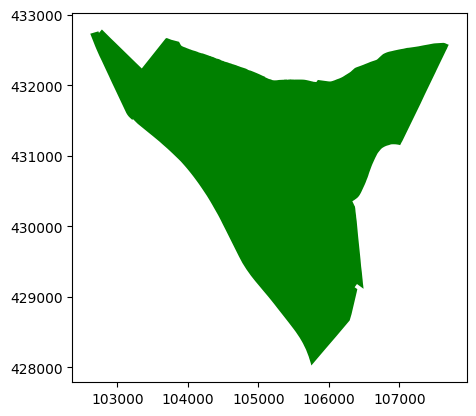

In [91]:
gemeente_gpkg_path = raw_data_dir / "bestuurlijkegrenzen.gpkg"
layers = fiona.listlayers(gemeente_gpkg_path)
print(layers)

Alblasserdam_gdf = gemeente_of_interest_geodf(gpkg_path=gemeente_gpkg_path, 
                                            layer_name='gemeenten', 
                                            gemeente='Alblasserdam')
Alblasserdam_gdf.plot(color='green')

# Alblasserdam_gdf.crs

Alblasserdam_gdf.to_file(proces_data_dir / "alblasserdam_shape.geojson")

* collections → collection metadata → items → parameters.
* ga naar de landing page, nr 6: ""The JSON representation of the list of all data layers (collections) 
served from this endpoint" Klik daarop. Dan kom je op https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections.
* Er zijn hier drie collections: buurten/gemeenten/wijken. Hier staat: Bekijk collectie als JSON. 
* Daarin vind je dan weer: https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections/buurten
* Now you can fetch the actual data: https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections/buurten/items?f=json&limit=1000


In [5]:
BASE = "https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1"
buurten_url = f"{BASE}/collections/buurten/items"

params = {
    "f": "json",
    "gemeentenaam": "Alblasserdam",  # filter to Alblasserdam
    "limit": 1000
}

response = requests.get(buurten_url, params=params)


if response.status_code == 200:
    raw = response.json()
else:
    print(f'Errro: {response.status_code}')

buurten_Alblasserdam = gpd.GeoDataFrame.from_features(raw["features"], crs = "EPSG: 28992")

(29, 224)
buurtnaam
Staatsliedenbuurt     1680
Florabuurt            1595
Schrijversbuurt       1590
kerkbuurt             1590
Schildersbuurt        1275
Vogelbuurt            1215
De Werven             1205
Cortgene               980
Blokweer Noord         950
Rivierenbuurt          925
Zeelt                  910
Drentsebuurt           905
Blokweer Zuid          775
Redersbuurt            635
Dijk                   620
Nieuw Kinderdijk       590
Middelland             570
Polderbuurt            525
Oranjebuurt            500
Klein Alblas           460
Waterland              440
Vinkenwaard            135
Polder Vinkenwaard     130
Polder Kortland         50
Polder Souburgh         30
Nieuwland               25
Groene Long             15
Polder Blokweer          5
Hoogendijk               0
Name: aantal_inwoners, dtype: int64


<Axes: >

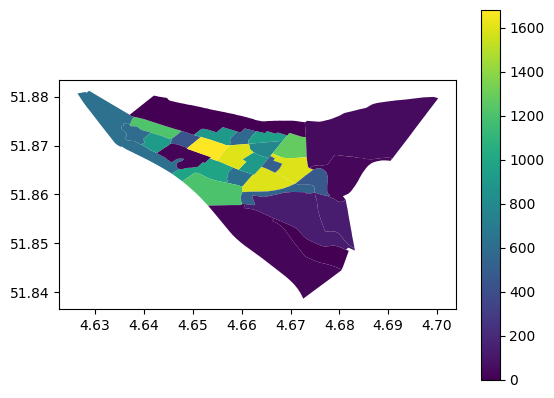

In [6]:
print(buurten_Alblasserdam.shape)
print(buurten_Alblasserdam.groupby('buurtnaam')['aantal_inwoners'].sum().sort_values(ascending=False))
buurten_Alblasserdam.plot(column='aantal_inwoners', legend=True, cmap='viridis')

### Ophalen boomhoogte rasterdata

In [ ]:
# download zip file van boomhoogte data - EENMALIG UITVOEREN
url = "https://data.rivm.nl/data/alo/rivm_20240101_boomhoogte_2022.zip"
response = requests.get(url)
dest = raw_data_dir / "boom_hoogte.zip"

with open(dest, 'wb') as file:
    file.write(response.content)

#unpack zipfile and save
zip_path = raw_data_dir / "boom_hoogte_kaart_nl.zip"    #unzip
extract_dir = raw_data_dir / "boom_hoogte"              #destination path
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:               #write unzipped to destination
    z.extractall(extract_dir)

In [ ]:
#bomen kaart openen en snijden met gemeentevector - EENMALIG UITVOEREN VOOR EEN GEMEENTE
boom_raster_path = raw_data_dir / "boom_hoogte" / "rivm_20240101_boomhoogte_2022.tif"   
proces_data_dir.mkdir(parents=True, exist_ok=True)  #save folder

#load and inspect raster
with rio.open(boom_raster_path) as boom_raster:
    print(boom_raster.crs)
    print(boom_raster.count)
    print(boom_raster.meta)

    # Extract geometry from GeoDataFrame
    geom_alblas = [json.loads(Alblasserdam_gdf.to_json())["features"][0]["geometry"]]

    #clip raster to Alblasserdam
    out_image, out_transform = mask(
        boom_raster,
        shapes=geom_alblas,
        crop=True
    )

    #prepare metadata - Copy and update metadata
    out_meta = boom_raster.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Output file path
tif_path_alblas_bomen = proces_data_dir / "alblasserdam_bomen.tif"

# Write clipped raster
with rio.open(tif_path_alblas_bomen, "w", **out_meta) as dst:
    dst.write(out_image)

# tif_path_alblas_bomen

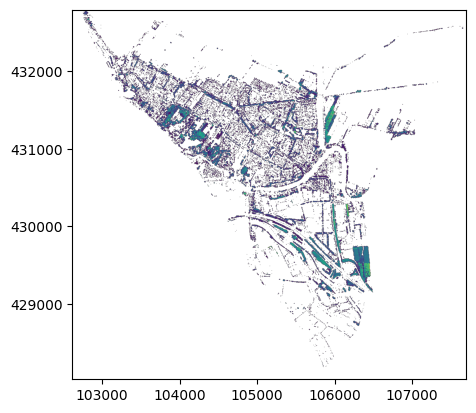

In [7]:
# checken of bomenkaart is geladen
tif_path_alblas_bomen = proces_data_dir / "alblasserdam_bomen.tif"
with rio.open(tif_path_alblas_bomen) as clipped_bomen_Alblasserdam:
    # print(clipped_bomen_Alblasserdam.meta)
    show(clipped_bomen_Alblasserdam)

### Data prep: RGB data, Infra data, DMS data

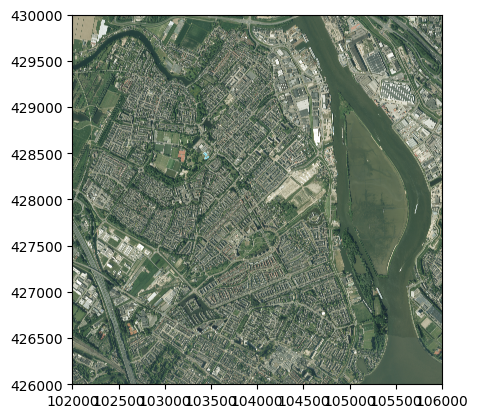

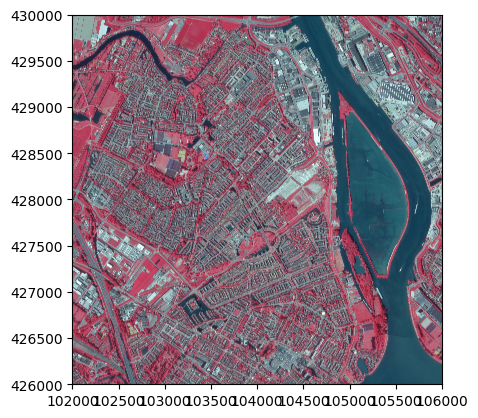

c:\Users\twand\Documents\Python\natural_capital\.venv\Lib\site-packages\matplotlib\colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


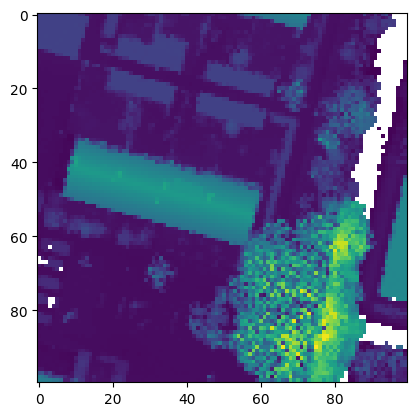

In [9]:
#testen of data succesvol kan worden ingeladen.
ortho_sample = "../data/raw/ortho_alblasserdam/2025_102000_430000_RGB_lrl.tif"
infra_sample = "../data/raw/infra_alblasserdam/2025_102000_430000_CIR_lrl.tif"
dsm_sample = "../data/raw/surface_model_05/R_38CN1.tif"

with rio.open(ortho_sample) as ortho:
    show(ortho)

with rio.open(infra_sample) as infra:
    show(infra)

with rio.open(dsm_sample) as dsm:
    my_window = Window(col_off=6600, row_off=6000, width=100, height=100)
    subset_masked = dsm.read(1, window=my_window, masked=True)
    show(subset_masked)

In [ ]:
#mergen van de vier ortho foto's (RGB en CIR) om ons totale gebied te dekken - EENMALIG UITVOEREN
tif_input_mosaic_rgb = raw_data_dir / "ortho_alblasserdam"
tif_output_mosaic_rgb = proces_data_dir / "RGB_tiles.tif"

tif_input_mosaic_infra = raw_data_dir / "infra_alblasserdam"
tif_output_mosaic_infra = proces_data_dir / "infra_tiles.tif"

merge_raster_to_mosaic(input_folder=tif_input_mosaic_rgb, 
                       output_file=tif_output_mosaic_rgb)


merge_raster_to_mosaic(input_folder=tif_input_mosaic_infra, 
                       output_file=tif_output_mosaic_infra)

#mergen van de vier hoogtemodellen (DTM-terrein en DSM-surface) om ons totale gebied te dekken - EENMALIG UITVOEREN
tif_input_mosaic_DTM05 = raw_data_dir / "terrain_model_05"     #EPSG:28992
tif_output_mosaic_DTM05 = proces_data_dir / "DTM05_tiles.tif"  #https://service.pdok.nl/rws/ahn/atom/dtm_05m.xml

tif_input_mosaic_DSM05 = raw_data_dir / "surface_model_05"     #EPSG:28992
tif_output_mosaic_DSM05 = proces_data_dir / "DSM05_tiles.tif"  #https://service.pdok.nl/rws/ahn/atom/dsm_05m.xml

merge_raster_to_mosaic(input_folder=tif_input_mosaic_DTM05, 
                       output_file=tif_output_mosaic_DTM05,
                       nodata=-9999.0)

merge_raster_to_mosaic(input_folder=tif_input_mosaic_DSM05, 
                       output_file=tif_output_mosaic_DSM05,
                       nodata=-9999.0)


Shape van subset: (80, 80)


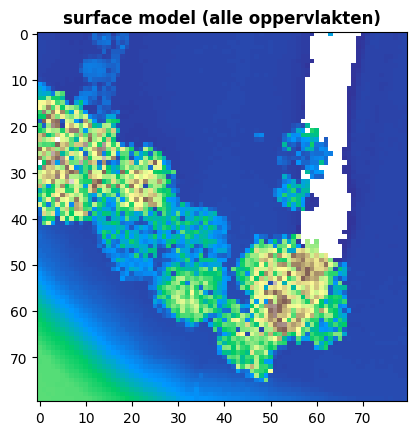

Shape van subset: (80, 80)


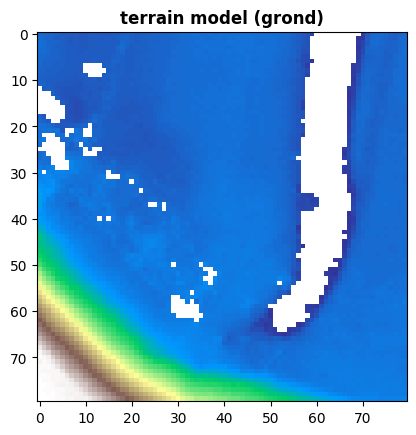

In [32]:
#test of de DTM en DSM kaarten (merged/mosaic) goed worden ingeladen
tif_output_mosaic_DSM05 = proces_data_dir / "DSM05_tiles.tif"
tif_output_mosaic_DTM05 = proces_data_dir / "DTM05_tiles.tif"

with rio.open(tif_output_mosaic_DSM05) as src:
    my_window = Window(col_off=6600, row_off=6180, width=80, height=80)
    subset_masked = src.read(1, window=my_window, masked=True)

    print(f"Shape van subset: {subset_masked.shape}")
    show(subset_masked, cmap='terrain', contour=False, title='surface model (alle oppervlakten)')

with rio.open(tif_output_mosaic_DTM05) as src:
    my_window = Window(col_off=6600, row_off=6180, width=80, height=80)
    subset_masked = src.read(1, window=my_window, masked=True)

    print(f"Shape van subset: {subset_masked.shape}")
    show(subset_masked, cmap='terrain', contour=False, title='terrain model (grond)')

In [ ]:
#Berekenen van normalized DSM - EENMALIG UITVOEREN
# 1. Lees DSM (Het Oppervlak / Ruw)
with rio.open(tif_output_mosaic_DSM05) as src_dsm:
    dsm_data = src_dsm.read(1, masked=True)  
    out_meta = src_dsm.profile.copy()       # Kopieer metadata van de DSM

# 2. Lees DTM (Het Maaiveld / Kaal)
with rio.open(tif_output_mosaic_DTM05) as src_dtm:
    dtm_data = src_dtm.read(1, masked=True)

# 3. Bereken nDSM (Oppervlak - Maaiveld)
ndsm_data = dsm_data - dtm_data

# 4. Update de metadata
out_meta.update({
    "driver": "GTiff",
    "dtype": 'float32',       # Zeker weten dat we floats opslaan
    "nodata": -9999.0         # NoData waarde
})

tif_output_mosaic_ndsm = proces_data_dir / "nDSM_full.tif"

# 5. Schrijf het bestand weg
with rio.open(tif_output_mosaic_ndsm, "w", **out_meta) as dst:
    dst.write(ndsm_data, 1)

print(f"Succesvol opgeslagen: {tif_output_mosaic_ndsm}")

Succesvol opgeslagen: C:\Users\twand\Documents\Python\natural_capital\data\processed\nDSM_full.tif


--- Statistieken nDSM Subset ---
Minimale hoogte: -0.01 m
Maximale hoogte: 15.76 m
Gemiddelde hoogte: 1.22 m


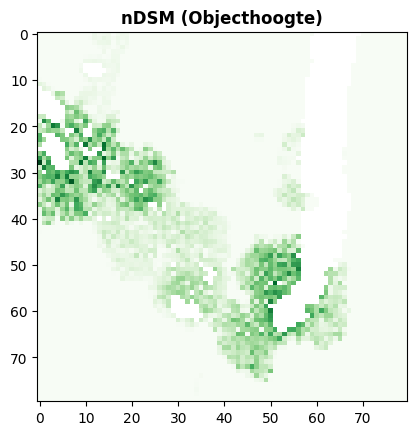

In [10]:
#test of nDSM werkt
import numpy as np

tif_output_mosaic_ndsm = proces_data_dir / "nDSM_full.tif"
my_window = Window(col_off=6600, row_off=6180, width=80, height=80)
with rio.open(tif_output_mosaic_ndsm) as src_ndsm:
    subset = src_ndsm.read(1, window=my_window, masked=True)

    print(f"--- Statistieken nDSM Subset ---")
    print(f"Minimale hoogte: {subset.min():.2f} m")
    print(f"Maximale hoogte: {subset.max():.2f} m")
    print(f"Gemiddelde hoogte: {subset.mean():.2f} m")
    
    show(subset, cmap='Greens', title='nDSM (Objecthoogte)')

### NDVI kaartlaag maken

Aantal bands: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32000, 'height': 32000, 'count': 3, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(0.25, 0.0, 102000.0,
       0.0, -0.25, 434000.0)}


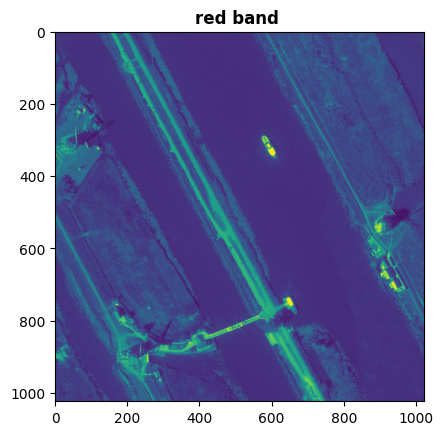

pixelgrootte: 0.25
Aantal bands: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32000, 'height': 32000, 'count': 3, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(0.25, 0.0, 102000.0,
       0.0, -0.25, 434000.0)}


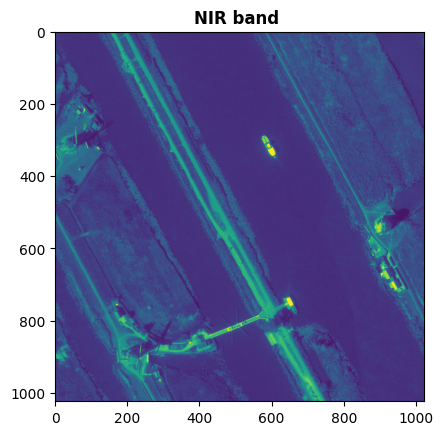

pixelgrootte: 0.25


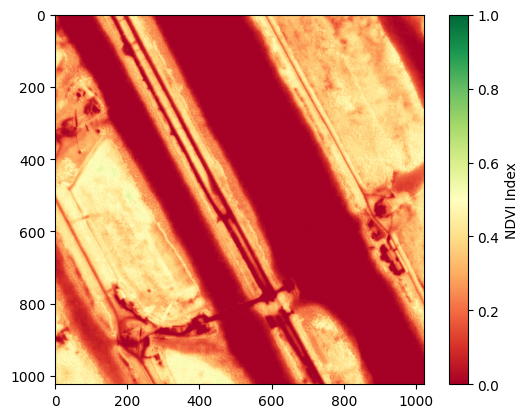

In [8]:
#check of de berekening werkt
tif_output_mosaic_rgb = proces_data_dir / "RGB_tiles.tif"
tif_output_mosaic_infra = proces_data_dir / "infra_tiles.tif"

my_window = Window(col_off=6000, row_off=3000, width=1024, height=1024)

with rio.open(tif_output_mosaic_rgb) as src:
    print(f"Aantal bands: {src.count}")
    print(src.meta)
    red = src.read(1, window=my_window, masked=True).astype('float32')    #Band 1=R, 2=G, 3=B
    show(red, title='red band ')
    print(f'pixelgrootte: {src.res[0]}')


with rio.open(tif_output_mosaic_infra) as src:
    print(f"Aantal bands: {src.count}")
    print(src.meta)
    nir = src.read(1, window=my_window, masked=True).astype('float32')
    show(red, title='NIR band ')
    print(f'pixelgrootte: {src.res[0]}')


ndvi = (nir - red) / (nir + red + 1e-10)
# plt.imshow(ndvi, cmap='RdYlGn')
plt.imshow(ndvi, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(label='NDVI Index')

Minimale waarde: -0.26
Maximale waarde: 0.69
Gemiddelde gemiddelde: 0.16


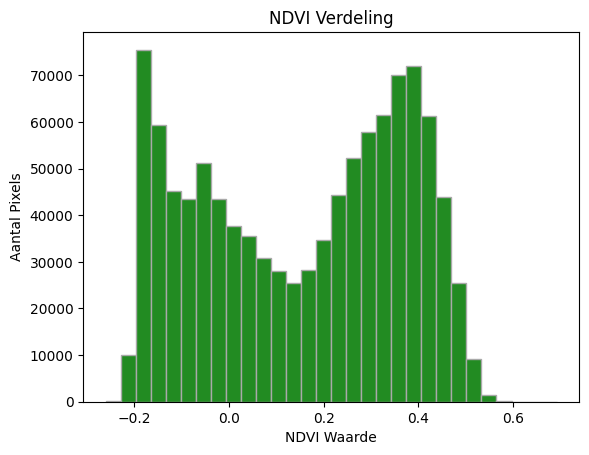

In [14]:
#check of de plots kloppen van de groenmaat (NDVI)
#graslanden of struikgewassen een NDVI waarde tussen de 0,2 en 0,4
#Bosvegetatie of hoogproductieve akkerbouw komen overeen met NDVI waardes hoger dan 0,4
#https://medium.com/@apratimonline/deep-dive-into-unsupervised-classification-of-satellite-images-k-means-pca-and-spectral-indices-442a5dc23219
print(f"Minimale waarde: {ndvi.min():.2f}")
print(f"Maximale waarde: {ndvi.max():.2f}")
print(f"Gemiddelde gemiddelde: {ndvi.mean():.2f}")
plt.hist(ndvi.compressed(), bins=30, color='forestgreen', edgecolor='darkgrey') # .compressed() is handig bij masked arrays: het verwijdert de NoData pixels
plt.title('NDVI Verdeling')
plt.xlabel('NDVI Waarde')
plt.ylabel('Aantal Pixels')
plt.show()

In [ ]:
#de NDVI daadwerkelijk berekenen - EENMALIG
tif_output_mosaic_rgb = proces_data_dir / "RGB_tiles.tif"
tif_output_mosaic_infra = proces_data_dir / "infra_tiles.tif"

with rio.open(tif_output_mosaic_rgb) as src:
    new_meta = src.meta.copy()

    print(f"Aantal bands: {src.count}")
    print(src.meta)

    red = src.read(1, masked=True).astype('float32')    #Band 1=R, 2=G, 3=B
    show(red, title='red band ')

with rio.open(tif_output_mosaic_infra) as src:
    
    print(f"Aantal bands: {src.count}")
    print(src.meta)

    nir = src.read(1, masked=True).astype('float32')
    show(nir, title='NIR band ')


ndvi = (nir - red) / (nir + red + 1e-10)
plt.imshow(ndvi, cmap='RdYlGn')

new_meta.update({
    "driver": "GTiff",
    "dtype": "float32",     
    "count": 1,             
    "nodata": -9999,        # Definieer NoData waarde
    "compress": "lzw"       
})

tif_output_NDVI_0008m = proces_data_dir / "NDVI_008m.tif"

# 5. Schrijf het bestand weg
with rio.open(tif_output_NDVI_0008m, "w", **new_meta) as dst:
    dst.write(ndvi.filled(-9999).astype('float32'), 1)

print(f"Succesvol opgeslagen: {tif_output_NDVI_0008m}")

Aantal bands: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32000, 'height': 32000, 'count': 3, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(0.25, 0.0, 102000.0,
       0.0, -0.25, 434000.0)}


### Upscalen naar zelfde niveau

In [20]:
#resample RGB
resample_raster(proces_data_dir / "RGB_tiles.tif", proces_data_dir / "RGB_05m.tif")

#resample NDVI
resample_raster(proces_data_dir / "NDVI_008m.tif", proces_data_dir / "NDVI_05m.tif")

#resample infra
resample_raster(proces_data_dir / "infra_tiles.tif", proces_data_dir / "infra_05m.tif")

Gereed: RGB_05m.tif is nu 0.5m resolutie.
Gereed: NDVI_05m.tif is nu 0.5m resolutie.
Gereed: infra_05m.tif is nu 0.5m resolutie.


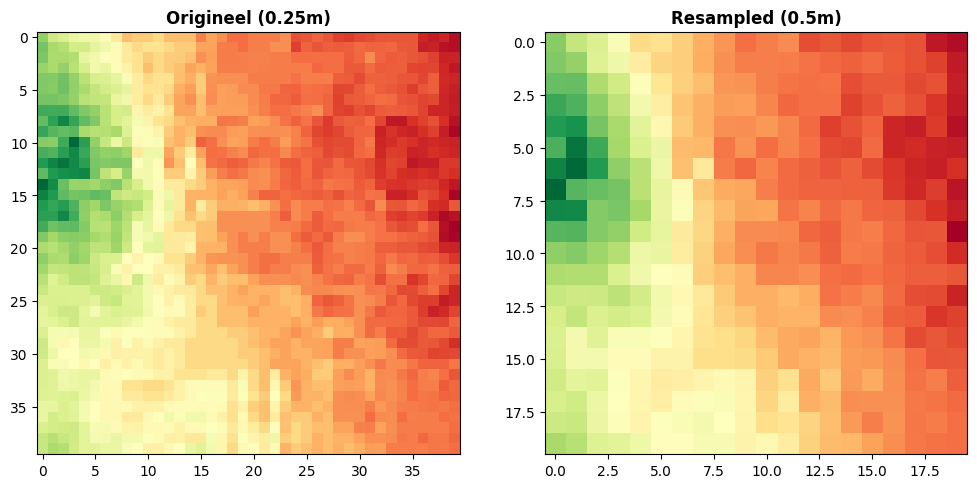

--- Statistiek Vergelijking (Subset) ---
Origineel - Min: -0.13, Max: 0.21, Mean: -0.01
Resampled - Min: -0.12, Max: 0.19, Mean: -0.01


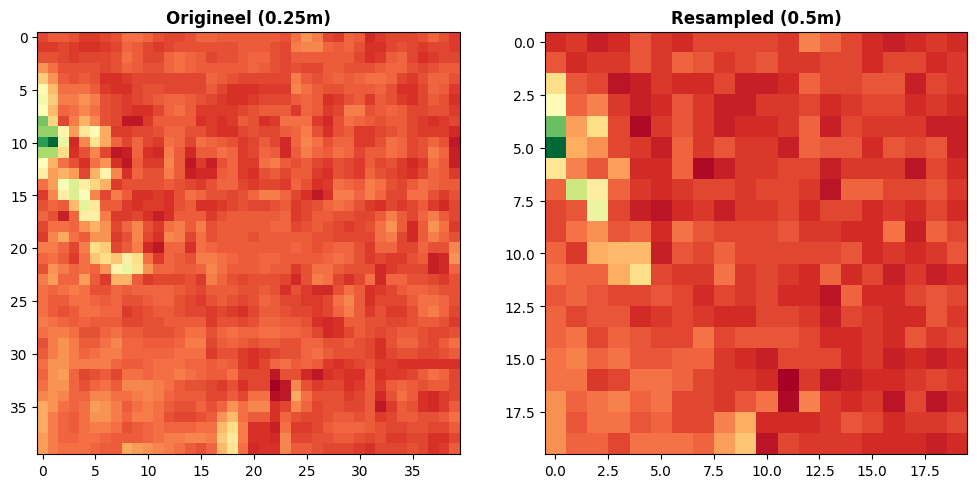

--- Statistiek Vergelijking (Subset) ---
Origineel - Min: 49.00, Max: 107.00, Mean: 59.18
Resampled - Min: 53.00, Max: 96.00, Mean: 59.29


In [22]:
# Resample check 
check_resampling(proces_data_dir / "NDVI_008m.tif", proces_data_dir / "NDVI_05m.tif")
check_resampling(proces_data_dir / "RGB_tiles.tif", proces_data_dir / "RGB_05m.tif")

In [24]:
with rio.open(proces_data_dir / "infra_05m.tif") as src:
    print(f"Aantal bands: {src.count}")      # Moet 3 zijn
    print(f"Bands: {src.indexes}")           # Moet (1, 2, 3) zijn
    print(f"Data type: {src.dtypes[0]}")     # Waarschijnlijk 'uint8' (0-255)

Aantal bands: 3
Bands: (1, 2, 3)
Data type: uint8


In [47]:
def create_feature_stack(output_path, ndsm_path, ndvi_path, rgb_path, infra_path):
    # We openen de NDVI als 'Master' om de maten en coördinaten te bepalen
    with rio.open(ndvi_path) as src_master:
        master_meta = src_master.meta.copy()
        master_bounds = src_master.bounds # De geografische grenzen van de 16k x 16k kaart
        h, w = src_master.height, src_master.width
        
        # Stap 1: Lees de lagen die al 16k x 16k zijn
        print("Lagen inlezen (16k x 16k)...")
        band_ndvi = src_master.read(1)
        
        with rio.open(rgb_path) as src_rgb:
            bands_rgb = src_rgb.read()
            
        with rio.open(infra_path) as src_infra:
            band_nir = src_infra.read(1) # We pakken alleen Band 1 (NIR)

        # Stap 2: De nDSM 'clippen' op het gebied van de master
        print("nDSM uitlijnen op de rest...")
        with rio.open(ndsm_path) as src_ndsm:
            # Bepaal welk venster (window) van de grote nDSM overeenkomt met de master_bounds
            window = src_ndsm.window(*master_bounds)
            # Lees de nDSM in dat venster, forceer de maat naar exact h, w
            band_ndsm = src_ndsm.read(1, window=window, out_shape=(h, w))

        # Stap 3: Stack maken (6 bands)
        layers = [
            np.expand_dims(band_ndsm, axis=0), # 1: Hoogte
            np.expand_dims(band_ndvi, axis=0), # 2: NDVI
            bands_rgb,                         # 3, 4, 5: R, G, B
            np.expand_dims(band_nir, axis=0)   # 6: NIR
        ]
        
        full_stack = np.concatenate(layers, axis=0).astype('float32')

        # Stap 4: Opslaan
        master_meta.update({
            "count": 6,
            "dtype": 'float32',
            "compress": 'lzw'
        })

        with rio.open(output_path, "w", **master_meta) as dst:
            dst.write(full_stack)
            dst.descriptions = ['nDSM', 'NDVI', 'Red', 'Green', 'Blue', 'NIR']
            
    print(f"Succes! Stack opgeslagen: {output_path.name}")
    print(f"Vorm van de stack: {full_stack.shape}")

In [48]:
# --- Uitvoeren ---
stack_path = proces_data_dir / "training_stack_05m.tif"
create_feature_stack(
    stack_path,
    proces_data_dir / "nDSM_full.tif",
    proces_data_dir / "NDVI_05m.tif",
    proces_data_dir / "RGB_05m.tif",
    proces_data_dir / "infra_05m.tif"
)

Lagen inlezen (16k x 16k)...
nDSM uitlijnen op de rest...
Succes! Stack opgeslagen: training_stack_05m.tif
Vorm van de stack: (6, 16000, 16000)


### Clip alle inputrasters naar gemeenteshape

band names:('nDSM', 'NDVI', 'Red', 'Green', 'Blue', 'NIR')
input raster is clipped by      code  gemeentenaam                                           geometry
314  0482  Alblasserdam  MULTIPOLYGON (((105906.013 428208.799, 105905.....
Saved as: C:\Users\twand\Documents\Python\natural_capital\data\processed\alblasserdam_testing_stack.tif
preview:
Preview van Band 1 (van de 6 bands):


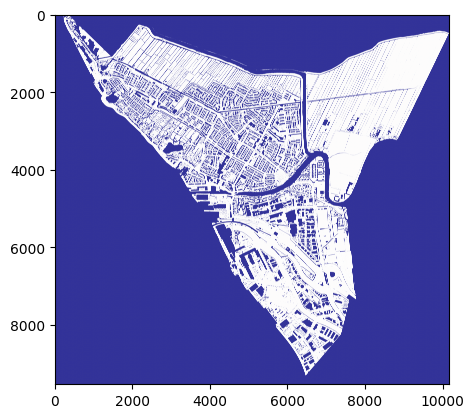

In [92]:
training_data_input = proces_data_dir / "training_stack_05m.tif"
alblasserdam_shape = proces_data_dir / "alblasserdam_shape.geojson"
alblasserdam_testing_stack = proces_data_dir / "alblasserdam_testing_stack.tif"

clip_raster_to_shape(input_raster_folder=training_data_input,
                     gemeente_geometry=Alblasserdam_gdf,
                     output_name=alblasserdam_testing_stack)

# with rio.open(alblasserdam_rgb) as clipped_infra_alblas:
#     # print(clipped_bomen_Alblasserdam.meta)
#     show(clipped_infra_alblas)

In [155]:
import rasterio as rio
from rasterio import features, windows
import geopandas as gpd
import pandas as pd
import numpy as np
import os

def maak_training_dataset_tiled(raster_path, vector_path, output_csv_path):
    """
    Zet een satellietbeeld en een vectorbestand om naar een CSV voor Machine Learning.
    Verwerkt de data in kleine blokjes (tiles) om geheugenproblemen te voorkomen.
    """
    # 1: Voorbereiding bestanden
    if os.path.exists(output_csv_path):
        os.remove(output_csv_path)
        print(f"Oud bestand verwijderd: {output_csv_path}")

    vector_data = gpd.read_file(vector_path) #de gelabelde polygonen

    # 2: Labels van polygonen omzetten naar getallen
    kolom_namen = ['boom', 'gras', 'gebouw', 'water_weg']
    name_to_num = {naam: i+1 for i, naam in enumerate(kolom_namen)}
    num_to_name = {v: k for k, v in name_to_num.items()}
    
    vector_data['label_naam'] = vector_data[kolom_namen].astype(float).idxmax(axis=1) #pakt de naam van de kolom die de hoogste waarde heef
    vector_data['label_nummer'] = vector_data['label_naam'].map(name_to_num) #converts text to the ID (name_to_num)
    
    print("Start met het verwerken van tegels (tiles)...")

    # 3: Satellietbeeld openen en verwerken
    with rio.open(raster_path) as satelliet_beeld:
        
        if vector_data.crs != satelliet_beeld.crs:
            print(f"Projecties verschillen. Vector wordt omgezet naar {satelliet_beeld.crs}")
            vector_data = vector_data.to_crs(satelliet_beeld.crs)
            
        band_namen = [satelliet_beeld.descriptions[i] or f"band_{i+1}" for i in range(satelliet_beeld.count)]
        
        is_eerste_blokje = True 

        # LOOP 
        for blok_index, venster in satelliet_beeld.block_windows(1):

            # A. in blokken laden
            venster_grenzen = windows.bounds(venster, satelliet_beeld.transform)
            xmin, ymin, xmax, ymax = venster_grenzen
            
            # B. zoek polygoon in blok
            polygonen_in_venster = vector_data.cx[xmin:xmax, ymin:ymax] #welke bomen zitten in dit venster?
            if polygonen_in_venster.empty:
                continue 

            # C. Rasteriseren: van de polygonen een grid maken met nummers (1=bomen 2=etc.)
            venster_transformatie = satelliet_beeld.window_transform(venster)
            vormen_en_labels = ((geom, waarde) for geom, waarde in zip(polygonen_in_venster.geometry, polygonen_in_venster['label_nummer']))
            
            label_masker = features.rasterize(
                shapes=vormen_en_labels,
                out_shape=(venster.height, venster.width),
                transform=venster_transformatie,
                fill=0,
                all_touched=True,
                dtype=rio.uint8
            )
            
            # D. Data Lezen
            pixel_data = satelliet_beeld.read(window=venster)
            
            # E. Plat slaan 3D (Height, Width, Bands) --> 2D (rows=Samples, columns=Features)
            aantal_banden = satelliet_beeld.count
            alle_pixel_waardes = pixel_data.reshape(aantal_banden, -1).T
            alle_pixel_labels = label_masker.reshape(-1)
                        
            # F. Haal de NoData waarde op. Vervang NoData door 0 in de hele array en Nan naar 0
            nodata_waarde = satelliet_beeld.nodata if satelliet_beeld.nodata is not None else -9999
            alle_pixel_waardes = alle_pixel_waardes.astype(float)
            alle_pixel_waardes[alle_pixel_waardes == nodata_waarde] = np.nan

            # G. Filteren. Maak mask om straks de <0 waardes weg te filteren.
            wel_data_masker = alle_pixel_labels > 0
            if wel_data_masker.sum() == 0:
                continue

            # Pas het filter toe. Bewaar de pixels waar label voor is (> 0).
            gefilterde_pixels = alle_pixel_waardes[wel_data_masker]
            gefilterde_labels = alle_pixel_labels[wel_data_masker]
            
            # H. Opslaan
            df_chunk = pd.DataFrame(gefilterde_pixels, columns=band_namen)
            df_chunk['label_id'] = gefilterde_labels
            df_chunk['label'] = df_chunk['label_id'].map(num_to_name)
            
            df_chunk.to_csv(output_csv_path, mode='a', header=is_eerste_blokje, index=False)
            is_eerste_blokje = False

    print(f"Klaar! De dataset is opgeslagen als: {output_csv_path}")

In [5]:
class_cols = ['boom', 'gras', 'gebouw', 'water_weg']

In [157]:
training_df = maak_training_dataset_tiled(
    raster_path=proces_data_dir / "training_stack_05m.tif",
    vector_path=external_data_dir / "boom_labels2.gpkg",
    output_csv_path=proces_data_dir / "bomen_training_dataset.csv"
)

Oud bestand verwijderd: C:\Users\twand\Documents\Python\natural_capital\data\processed\bomen_training_dataset.csv
Start met het verwerken van tegels (tiles)...


C:\Users\twand\AppData\Local\Temp\ipykernel_5196\532091335.py:25: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  vector_data['label_naam'] = vector_data[kolom_namen].astype(float).idxmax(axis=1) #pakt de naam van de kolom die de hoogste waarde heef


Klaar! De dataset is opgeslagen als: C:\Users\twand\Documents\Python\natural_capital\data\processed\bomen_training_dataset.csv


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
import pandas as pd

In [9]:
training_csv = proces_data_dir / "bomen_training_dataset.csv"
training_df = pd.read_csv(training_csv)

In [39]:
print(training_df.shape)
print(training_df.sample(5))
print(training_df.label.value_counts())

(3294667, 8)
           nDSM      NDVI    Red  Green   Blue    NIR  label_id      label
1098894     NaN -0.057619  138.0  143.0  120.0  123.0         3     gebouw
1826927  0.0000 -0.408595   73.0   91.0   75.0   31.0         4  water_weg
1681215  0.0000 -0.394511  101.0  114.0   88.0   44.0         4  water_weg
313910   1.3977  0.636901   31.0   55.0   42.0  137.0         1       boom
465592   0.0000  0.243877  111.0  125.0   94.0  182.0         2       gras
label
water_weg    2317508
gras          458622
gebouw        290089
boom          228448
Name: count, dtype: int64


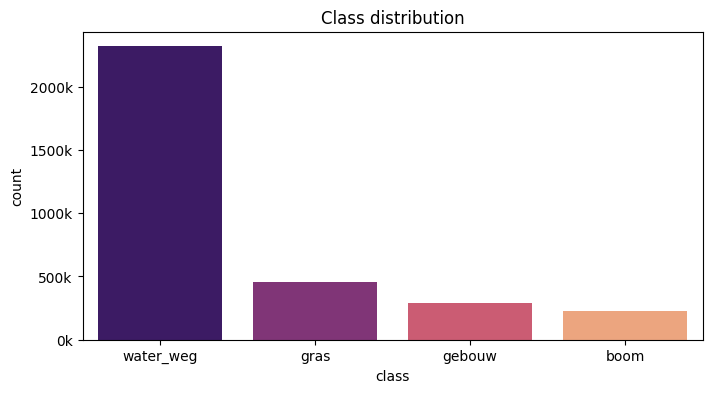

In [11]:
plt.figure(figsize=(8,4))

ax = sns.countplot(x='label', data=training_df, hue='label', palette='magma')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))

plt.title('Class distribution')
plt.xlabel('class')
plt.ylabel('count')
plt.show()

In [13]:
def manual_undersample(df, label_col='label_id'):
    min_size = training_df[label_col].value_counts().min()
    balanced_df = training_df.groupby(label_col).sample(n=min_size, random_state=87)
    
    return balanced_df.sample(frac=1).reset_index(drop=True)

df_balanced = manual_undersample(training_df)

In [14]:
X_final = df_balanced.drop(['label_id', 'label'], axis=1)
y_final = df_balanced['label_id']

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

In [18]:
numeric_features = X_train.columns.tolist()

In [19]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    ])

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
        ])

In [21]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=87))
])

In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=5)

param_grid = {
    'classifier__learning_rate': [0.1],                 # 0.1 is de standaard, 0.05 is voorzichtiger
    'classifier__max_iter': [150, 200],                 # Meer iteraties is vaak beter bij boosting
    'classifier__max_leaf_nodes': [63, 80],             # 31 is default, 63 maakt complexere bomen
    'classifier__l2_regularization': [0.1, 1]           # Helpt tegen overfitting bij nDSM uitschieters
}

estimator = GridSearchCV(pipe,
                          param_grid,
                          scoring='accuracy',
                          cv=5,
                          n_jobs=4,
                          verbose=3)

#Fitten en Scoren
estimator.fit(X_train, y_train)
print(f'beste params:{estimator.best_params_}')
print(f'test score: {estimator.score(X_test, y_test)} ' )

Fitting 5 folds for each of 8 candidates, totalling 40 fits
beste params:{'classifier__l2_regularization': 1, 'classifier__learning_rate': 0.1, 'classifier__max_iter': 200, 'classifier__max_leaf_nodes': 80}
test score: 0.9782500451414158 


In [23]:
best_model = estimator.best_estimator_
y_pred = best_model.predict(X_test)

In [83]:
result = pd.DataFrame(estimator.cv_results_)
result.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__l2_regularization,param_classifier__learning_rate,param_classifier__max_iter,param_classifier__max_leaf_nodes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,21.230465,1.025332,3.087881,0.175173,0.1,0.1,150,63,"{'classifier__l2_regularization': 0.1, 'classi...",0.978271,0.978387,0.978182,0.977812,0.978106,0.978151,0.000194,8
1,25.471145,0.655464,3.289799,0.108233,0.1,0.1,150,80,"{'classifier__l2_regularization': 0.1, 'classi...",0.978483,0.978674,0.978421,0.978093,0.978435,0.978421,0.000188,6
2,29.307663,0.539127,4.395615,0.032137,0.1,0.1,200,63,"{'classifier__l2_regularization': 0.1, 'classi...",0.978578,0.978708,0.978305,0.978223,0.978305,0.978424,0.000186,5
3,28.858151,1.604186,4.221609,0.164340,0.1,0.1,200,80,"{'classifier__l2_regularization': 0.1, 'classi...",0.978606,0.978606,0.978633,0.978277,0.978660,0.978556,0.000141,2
4,22.229320,0.554153,3.614969,0.176617,1.0,0.1,150,63,"{'classifier__l2_regularization': 1, 'classifi...",0.978394,0.978325,0.978277,0.977860,0.978161,0.978203,0.000188,7


In [26]:
performance_table = result.groupby(['param_classifier__learning_rate', 'param_classifier__max_iter', 'param_classifier__max_leaf_nodes'])[['mean_test_score']].mean()
performance_table

mean_test_score
param_classifier__learning_rate param_classifier__max_iter param_classifier__max_leaf_nodes                 
0.1                             150                        63                                       0.978177
                                                           80                                       0.978474
                                200                        63                                       0.978439
                                                           80                                       0.978615

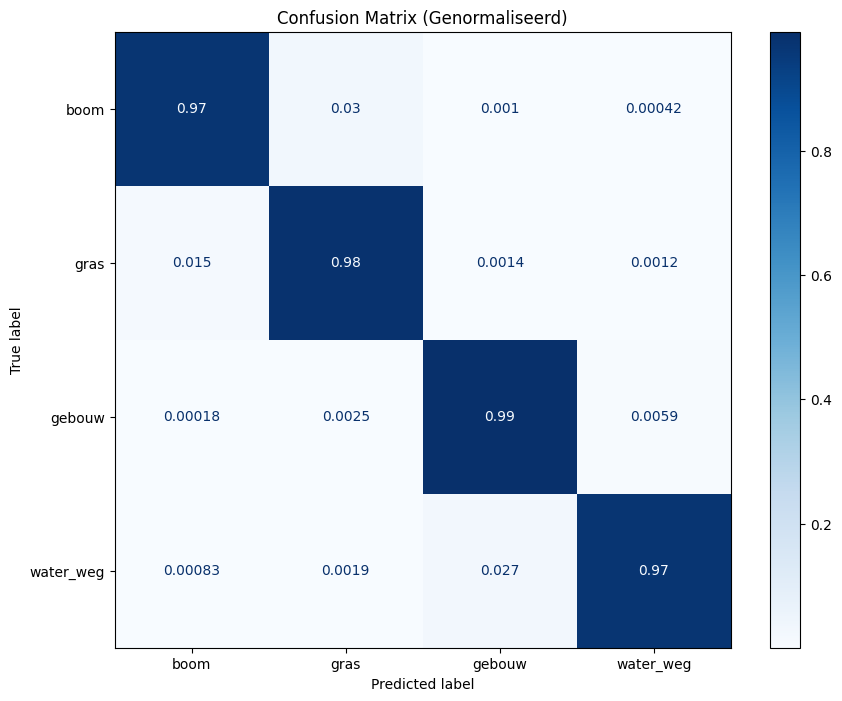

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Maak de plot direct vanuit het model
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_estimator(
    best_model, 
    X_test, 
    y_test, 
    display_labels=['boom', 'gras', 'gebouw', 'water_weg'], # Of gebruik je dict: num_to_name.values()
    cmap='Blues',
    normalize='true', # 'true' toont percentages, laat weg voor aantallen
    ax=ax
)

plt.title("Confusion Matrix (Genormaliseerd)")
plt.show()

### twijfelgevallen analyse

In [84]:
print(best_model.classes_)
num_to_label = {1: 'boom', 2: 'gras', 3:'gebouw', 4: 'water_weg'}
target_id = best_model.classes_[0]
target_label = num_to_label[target_id]
print(f"Index 1 in predict_proba hoort bij ID {target_id}, oftewel: {target_label}")
print(X_test.columns)

[1 2 3 4]
Index 1 in predict_proba hoort bij ID 1, oftewel: boom
Index(['nDSM', 'NDVI', 'Red', 'Green', 'Blue', 'NIR'], dtype='object')


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

#nieuwe DF maken met probabilities
boom_evaluatie_df = X_test.copy()

boom_evaluatie_df['ground_truth_id'] = y_test.values
boom_evaluatie_df['voorspelt_id'] = y_pred
boom_evaluatie_df['kans_boom'] = best_model.predict_proba(X_test)[:, 0] 

#labels terugplakken (nu codes. Zie num_to_label,)
boom_evaluatie_df['ground_truth'] = boom_evaluatie_df['ground_truth_id'].map(num_to_label)
boom_evaluatie_df['voorspelt'] = boom_evaluatie_df['voorspelt_id'].map(num_to_label)
boom_evaluatie_df['correct'] = np.where(boom_evaluatie_df['ground_truth'] != boom_evaluatie_df['voorspelt'], 'slecht_voorspelt', 'goed_voorspelt')

# Filteren op twijfelgevallen
twijfelgevallen = boom_evaluatie_df[boom_evaluatie_df['kans_boom'].between(0.45, 0.65)]
print(f"Aantal twijfelgevallen: {len(twijfelgevallen)}")

#filteren op twijfelgevallen enkel slecht voorpelde
twijfelgevallen_slecht = boom_evaluatie_df.loc[
    (boom_evaluatie_df['kans_boom'].between(0.45, 0.65)) & 
    (boom_evaluatie_df['correct'] == 'slecht_voorspelt')
]
print(f"Aantal twijfelgevallen (slecht): {len(twijfelgevallen_slecht)}")

features_to_check = ['nDSM', 'NDVI', 'kans_boom'] 
print("\nGemiddelde waardes van twijfelgevallen:")
print(twijfelgevallen_slecht[features_to_check].mean())
print("\nCheck van eerste 10 twijfelgevallen:")
print(twijfelgevallen_slecht[features_to_check + ['ground_truth', 'voorspelt', 'correct']].sample(5))


analysis = twijfelgevallen_slecht.groupby(['ground_truth', 'voorspelt']).agg(
    count=('correct', 'size'),
    avg_NDSM=('nDSM', 'mean'),
    avg_NDVI=('NDVI', 'mean')
)

print(analysis)



Aantal twijfelgevallen: 756
Aantal twijfelgevallen (slecht): 347

Gemiddelde waardes van twijfelgevallen:
nDSM         0.741032
NDVI         0.421399
kans_boom    0.547248
dtype: float64

Check van eerste 10 twijfelgevallen:
        nDSM      NDVI  kans_boom ground_truth voorspelt           correct
597601   NaN  0.501862   0.497325         boom      gras  slecht_voorspelt
443082   0.0  0.340774   0.523448         gras      boom  slecht_voorspelt
760265   NaN  0.452031   0.491056         boom      gras  slecht_voorspelt
555218   0.0  0.269260   0.520084         gras      boom  slecht_voorspelt
652096   0.0  0.348330   0.557490         gras      boom  slecht_voorspelt
                        count  avg_NDSM  avg_NDVI
ground_truth voorspelt                           
boom         gras          91  1.851081  0.437075
gebouw       boom           1  3.424300  0.127118
gras         boom         247  0.531983  0.423518
water_weg    boom           8  0.830720  0.214441


### Beste model maken en opslaan

In [85]:
import joblib
model_path = home_dir / "src"

final_model = estimator.best_estimator_
model_bestandsnaam = model_path / "hgbc_model_drechtsteden_v1.pkl"
joblib.dump(final_model, model_bestandsnaam)

print(f'bestand opgeslagen in {model_path}' )

bestand opgeslagen in C:\Users\twand\Documents\Python\natural_capital\src


### Inferentie op Alblasserdam

In [101]:
import rasterio as rio
import joblib
import numpy as np
import pandas as pd # Vergeet deze niet!

# 1. Voorbereiding
hgbc_from_joblib = joblib.load(model_path / "hgbc_model_drechtsteden_v1.pkl")
alblasserdam_testing_stack = proces_data_dir / "alblasserdam_testing_stack.tif"
output_8_layers = "Alblasserdam_Inference_Stack_8L.tif"

with rio.open(alblasserdam_testing_stack) as src:
    feature_namen = src.descriptions
    out_meta = src.meta.copy()
    out_meta.update(count=8) 

    # Bepaal boom-index buiten de loop (efficiënter)
    boom_class_index = list(hgbc_from_joblib.classes_).index(1)

    with rio.open(output_8_layers, "w", **out_meta) as dst:
        # Optioneel: zet de namen alvast klaar
        output_namen = list(feature_namen) + ['Classificatie', 'Boom_Kans']
        
        for block_index, venster in src.block_windows(1):
            img_block = src.read(window=venster)
            
            # Van 3D naar 2D
            pixels_np = img_block.reshape(src.count, -1).T 
            pixels_df = pd.DataFrame(pixels_np, columns=feature_namen)
            
            # Zorg voor de juiste kolomvolgorde voor het model!
            pixels_df = pixels_df[list(hgbc_from_joblib.feature_names_in_)]

            # Voorspellen
            labels_1D = hgbc_from_joblib.predict(pixels_df)
            probas_all = hgbc_from_joblib.predict_proba(pixels_df)
            tree_probas_1D = probas_all[:, boom_class_index]

            # Terug naar 2D
            labels_2D = labels_1D.reshape((1, venster.height, venster.width))
            tree_probas_2D = tree_probas_1D.reshape((1, venster.height, venster.width))

            # Schrijven
            dst.write(img_block, window=venster, indexes=[1, 2, 3, 4, 5, 6])
            dst.write(labels_2D.astype(out_meta['dtype']), window=venster, indexes=7)
            dst.write(tree_probas_2D.astype(out_meta['dtype']), window=venster, indexes=8)
            
        # Namen toevoegen aan de banden
        for i, naam in enumerate(output_namen):
            dst.set_description(i + 1, naam)

print("Klaar! Alblasserdam is nu een 8-laags intelligent raster.")

ValueError: Source shape (1, 1, 1, 10168) is inconsistent with given indexes 1

### Tiles maken voor batch verwerking

In [ ]:
def generate_tiles(input_dir_tiles: Path,
                   tile_output_dir: Path, 
                   tile_size: int = 256, 
                   overlap_pct: float = 0.5, #naar 0 als geen overlap
                   ) -> None:
    """
    Een functie die image tiles maakt vanuit een bepaalde directory en deze opslaat in een nieuwe folder.

    Args:
        input_dir_tiles: The directory path where the tiles are located.
        tilesize: The size (width/height) of each tile in pixels. Defaults to 256.
        overlap_pct: The percentage of overlap between tiles (0.0 to 1.0).
    """
    STEP = int(tile_size * (1-overlap_pct))

    if not tile_output_dir:
        print('creating default directory to save tiles')
        tile_output_dir = Path('./output_tiles')
        print(f'path created at: {tile_output_dir}') 

    tile_output_dir.mkdir(parents=True, exist_ok=True)

    print(f'starting processing: {input_dir_tiles}')
    print(f'tile size: {tile_size}px, Step: {STEP}px')

    with rio.open(input_dir_tiles) as src:
        meta = src.meta.copy()

        # Loop over de X en Y as (Grid)
        for col_off in range(0, src.width - tile_size, STEP):
            for row_off in range(0, src.height - tile_size, STEP):

                # Definieer het venster (window) dat we gaan lezen
                window = Window(col_off, row_off, tile_size, tile_size)
        
                # Lees de data binnen dit venster
                tile_data = src.read(window=window)

                tile_transform = src.window_transform(window)
                
                # Update metadata voor de kleine tile
                meta.update({
                    "driver": "GTiff",
                    "height": tile_size,
                    "width": tile_size,
                    "transform": tile_transform
                })
                
                # Bestandsnaam genereren (bv: tile_1024_2048.tif)
                tile_name = f"tile_{col_off}_{row_off}.tif"
                out_path = tile_output_dir / tile_name
                
                # Schrijf de tile weg naar schijf
                with rio.open(out_path, "w", **meta) as dest:
                    dest.write(tile_data)
                    
    print(f"Klaar. Tiles opgeslagen in: {tile_output_dir}")

In [ ]:
tile_output_dir = proces_data_dir / "tiles_created_rgb"
tile_size = 256 # 256x256 pixels (~20x20m bij 8cm resolutie)
overlap_pct = 0.5

generate_tiles(input_dir_tiles=tif_output_mosaic_rgb,
               tile_output_dir=tile_output_dir,
               tile_size=tile_size,
               overlap_pct=overlap_pct)

starting processing: C:\Users\twand\Documents\Python\natural_capital\data\processed\RGB_tiles.tif
tile size: 256px, Step: 128px
Klaar! Tiles opgeslagen in: C:\Users\twand\Documents\Python\natural_capital\data\processed\tiles_created_rgb


https://medium.com/@apratimonline/deep-dive-into-unsupervised-classification-of-satellite-images-k-means-pca-and-spectral-indices-442a5dc23219

### Bomen 'maken' met Random Forest model (RFM)
* Er is geen goede bomenkaart op gemeenteniveau. Enkel grote gemeentes hebben accurate data van hun bomenbestand. Daarom, o.b.v. diverse type satellietbeelden kunnen we een inferentie doen van welke pixels 'boom' zijn en welke niet.
* Hiervoor moet eerst trainingsdata worden gelabeld in Qgis zodat het model wat voorbeelden heeft. 
* Vervolgens inferentie van 'Boompixels' die we schatten met RFM. Vervolgens pixels samenvoegen tot 'boom' eenheden

### Scoping out the main ecosystem services. Ophalen data van biofysieke flows van bomen:
* CO2 opslag
* waterretentie
* Luchtvervuiling opname
* geluidsreductie
* Aestethiek
* Recreationele waarde
* Lokaal microklimaat (afkoeling)


### Ophalen monetaire kentallen ecosysteemdiensten:
* CO2 opslag
* waterretentie
* Luchtvervuiling opname
* geluidsreductie
* Aestethiek
* Recreationele waarde
* Lokaal microklimaat (afkoeling)



### interactieve kaart - voor later

In [ ]:
import leafmap
# url = "https://fsn1.your-objectstorage.com/hwh-ortho/2022/Ortho/4/70/beelden_tif_tegels/2022_105000_431000_RGB_hrl.tif"
m = leafmap.Map(center=(40, -100), zoom=4)

tif_path = proces_data_dir / "nDSM_full.tif"

m.add_raster(
    str(tif_path),
    layer_name="alblasserdam_bomen",
    colormap="terrain",
    opacity=0.95,
)

m

Map(center=[51.867534000000006, 4.661148000000001], controls=(ZoomControl(options=['position', 'zoom_in_text',…